# Notebook 09 — Full Combined Analysis & Paper-Ready Plots

Loads ALL results (MLP + CNN, baselines + certified + concolic) and produces
the complete set of tables and figures for the TAI paper.

**Requires ALL previous notebooks to have been run:**
```
results/baselines_summary.json          (Notebook 02)
results/marabou_small_mnist.json        (Notebook 03)
results/concolic_summary.json           (Notebook 04)
results/cnn_training_summary.json       (Notebook 06)
results/certified_summary.json          (Notebook 07)
results/concolic_lenet5_mnist.json      (Notebook 08)
results/concolic_smallcnn_cifar.json    (Notebook 08)
results/cnn_cache_analysis.json         (Notebook 08)
```

**Outputs:**
```
results/figures/fig_main_comparison.pdf   — Table I full comparison
results/figures/fig_certified_vs_heuristic.pdf
results/figures/fig_scalability_all.pdf
results/figures/fig_cache_analysis.pdf
results/figures/fig_bound_gap_all.pdf
results/tables/table1_main.json
results/tables/table2_certified.json
results/tables/table3_cnn.json
```

In [1]:
import subprocess, sys
for pkg in ['matplotlib', 'numpy', 'scipy']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'], check=False)
import matplotlib
print(f'matplotlib: {matplotlib.__version__}')

matplotlib: 3.10.9


In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

REPO_ROOT   = Path(os.getcwd())
sys.path.insert(0, str(REPO_ROOT))
from utils.metrics import load_results, save_results

RESULTS_DIR = REPO_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
TABLES_DIR  = RESULTS_DIR / 'tables'
for d in [FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.titlesize' : 12,
    'axes.labelsize' : 11,
    'legend.fontsize': 10,
    'figure.dpi'     : 150,
    'savefig.dpi'    : 300,
    'savefig.bbox'   : 'tight',
    'axes.grid'      : True,
    'grid.alpha'     : 0.3,
})

COLORS = {
    'fgsm'     : '#E69F00',
    'pgd'      : '#56B4E9',
    'concolic' : '#009E73',
    'ibp'      : '#CC79A7',
    'crown'    : '#D55E00',
    'lp_exact' : '#0072B2',
}

def savefig(name):
    for ext in ['pdf', 'png']:
        plt.savefig(FIGURES_DIR / f'{name}.{ext}')
    print(f'  Saved -> {name}.pdf / .png')

print('Config ready.')

Config ready.


## 1 — Load all results

In [3]:
print('Loading MLP results...')
bl_sum   = load_results(str(RESULTS_DIR / 'baselines_summary.json'))
co_sum   = load_results(str(RESULTS_DIR / 'concolic_summary.json'))
exact_s  = load_results(str(RESULTS_DIR / 'marabou_small_mnist.json'))

# per-sample arrays for MLP
bl_small  = load_results(str(RESULTS_DIR / 'baselines_small_mnist.json'))
bl_medium = load_results(str(RESULTS_DIR / 'baselines_medium_mnist.json'))
bl_large  = load_results(str(RESULTS_DIR / 'baselines_large_cifar.json'))
co_small  = load_results(str(RESULTS_DIR / 'concolic_small_mnist.json'))
co_medium = load_results(str(RESULTS_DIR / 'concolic_medium_mnist.json'))
co_large  = load_results(str(RESULTS_DIR / 'concolic_large_cifar.json'))

print('Loading CNN results...')
cert_sum  = load_results(str(RESULTS_DIR / 'certified_summary.json'))
cert_smlp = load_results(str(RESULTS_DIR / 'certified_small_mnist.json'))
cert_l5   = load_results(str(RESULTS_DIR / 'certified_lenet5_mnist.json'))
cert_cnn  = load_results(str(RESULTS_DIR / 'certified_smallcnn_cifar.json'))
co_l5     = load_results(str(RESULTS_DIR / 'concolic_lenet5_mnist.json'))
co_cnn    = load_results(str(RESULTS_DIR / 'concolic_smallcnn_cifar.json'))
cache_a   = load_results(str(RESULTS_DIR / 'cnn_cache_analysis.json'))
cnn_train = load_results(str(RESULTS_DIR / 'cnn_training_summary.json'))

print('All results loaded.')

# ── helper arrays ─────────────────────────────────────────────────────────────
def get_ps(result, key='eps_upper'):
    """Extract per-sample array from a result dict."""
    if 'per_sample' in result:
        return np.array([r[key] for r in result['per_sample']])
    return np.array([])

def get_bl(bl_res, method, key='eps_upper'):
    return np.array([r[key] for r in bl_res[method]['per_sample']])

def get_cert(cert_res, method, key='eps_certified'):
    return np.array([r[key] for r in cert_res[method]['per_sample']])

print('Helper functions defined.')

Loading MLP results...
  Loaded results ← D:\concolic_exploration\results\baselines_summary.json
  Loaded results ← D:\concolic_exploration\results\concolic_summary.json
  Loaded results ← D:\concolic_exploration\results\marabou_small_mnist.json
  Loaded results ← D:\concolic_exploration\results\baselines_small_mnist.json
  Loaded results ← D:\concolic_exploration\results\baselines_medium_mnist.json
  Loaded results ← D:\concolic_exploration\results\baselines_large_cifar.json
  Loaded results ← D:\concolic_exploration\results\concolic_small_mnist.json
  Loaded results ← D:\concolic_exploration\results\concolic_medium_mnist.json
  Loaded results ← D:\concolic_exploration\results\concolic_large_cifar.json
Loading CNN results...
  Loaded results ← D:\concolic_exploration\results\certified_summary.json
  Loaded results ← D:\concolic_exploration\results\certified_small_mnist.json
  Loaded results ← D:\concolic_exploration\results\certified_lenet5_mnist.json
  Loaded results ← D:\concolic_ex

## 2 — Table I: Full Method Comparison
All models, all methods, all metrics

In [4]:
rows = []
print('TABLE I: Full Method Comparison')
print('='*90)
hdr = f'{"Model":<20} {"Method":<10} {"eps_upper":>10} {"eps_lower":>10} {"Cert%":>6} {"Adv%":>6} {"t/s":>8}'
print(hdr); print('-'*90)

configs = [
    # (display_name, fgsm_src, pgd_src, concolic_src, cert_src, n_relu)
    ('Small-MLP(128)',   bl_small,  co_small['stats'],  cert_smlp,  128),
    ('Medium-MLP(768)',  bl_medium, co_medium['stats'], None,       768),
    ('Large-MLP(2048)',  bl_large,  co_large['stats'],  None,      2048),
    ('LeNet5(MNIST)',    None,      co_l5['stats'],     cert_l5,    None),
    ('SmallCNN(CIFAR)',  None,      co_cnn['stats'],    cert_cnn,   None),
]

for (mname, bl_src, co_stats, cert_src, n_relu) in configs:
    # FGSM (MLP only)
    if bl_src is not None:
        for meth in ['fgsm', 'pgd']:
            s = bl_src[meth]['stats']
            row = dict(model=mname, method=meth.upper(),
                       eps_upper=s['mean_eps_upper'], eps_lower=0.0,
                       cert_pct=0.0,
                       adv_pct=s['fraction_adversarial_found']*100,
                       time=s['mean_runtime_sec'])
            rows.append(row)
            print(f"  {mname:<20} {meth.upper():<10}"
                  f" {s['mean_eps_upper']:>10.4f} {'---':>10}"
                  f" {'---':>6} {s['fraction_adversarial_found']*100:>5.1f}%"
                  f" {s['mean_runtime_sec']:>8.3f}s")

    # IBP + CROWN (if available)
    if cert_src is not None:
        for meth in ['ibp', 'crown']:
            s = cert_src[meth]['stats']
            row = dict(model=mname, method=meth.upper(),
                       eps_upper=0.0, eps_lower=s['mean_eps_certified'],
                       cert_pct=s['fraction_certified']*100,
                       adv_pct=0.0, time=s['mean_runtime_sec'])
            rows.append(row)
            print(f"  {mname:<20} {meth.upper():<10}"
                  f" {'---':>10} {s['mean_eps_certified']:>10.4f}"
                  f" {s['fraction_certified']*100:>5.1f}% {'---':>6}"
                  f" {s['mean_runtime_sec']:>8.3f}s")

    # Concolic (all models)
    s = co_stats
    row = dict(model=mname, method='Concolic',
               eps_upper=s['mean_eps_upper'], eps_lower=s['mean_eps_lower'],
               cert_pct=0.0,
               adv_pct=s['fraction_adversarial_found']*100,
               time=s['mean_runtime_sec'])
    rows.append(row)
    print(f"  {mname:<20} {'Concolic':<10}"
          f" {s['mean_eps_upper']:>10.4f} {s['mean_eps_lower']:>10.4f}"
          f" {'---':>6} {s['fraction_adversarial_found']*100:>5.1f}%"
          f" {s['mean_runtime_sec']:>8.3f}s")
    print('-'*90)

save_results(rows, str(TABLES_DIR / 'table1_main.json'))
print('Table I saved.')

TABLE I: Full Method Comparison
Model                Method      eps_upper  eps_lower  Cert%   Adv%      t/s
------------------------------------------------------------------------------------------
  Small-MLP(128)       FGSM           0.1640        ---    --- 100.0%    0.023s
  Small-MLP(128)       PGD            0.1286        ---    --- 100.0%    0.281s
  Small-MLP(128)       IBP               ---     0.0085  98.0%    ---    0.007s
  Small-MLP(128)       CROWN             ---     0.0093  98.0%    ---    0.010s
  Small-MLP(128)       Concolic       0.1743     0.1395    --- 100.0%    0.038s
------------------------------------------------------------------------------------------
  Medium-MLP(768)      FGSM           0.2631        ---    ---  99.0%    0.031s
  Medium-MLP(768)      PGD            0.1917        ---    --- 100.0%    0.428s
  Medium-MLP(768)      Concolic       0.2407     0.2291    --- 100.0%    0.051s
---------------------------------------------------------------------

## 3 — Table II: Tightness vs LP Ground Truth (Small-MLP)

In [5]:
from utils.metrics import tightness_score

exact_valid = [r for r in exact_s['per_sample'] if not r['timed_out']]
n_valid = len(exact_valid)

print(f'TABLE II: Tightness vs LP Ground Truth (Small-MLP, n={n_valid})')
print('='*55)

if n_valid >= 5:
    eps_true = np.array([r['eps_star'] for r in exact_valid])
    n = min(n_valid, len(get_bl(bl_small,'fgsm')))

    table2 = []
    for mname, eps_est in [
        ('FGSM',    get_bl(bl_small,'fgsm')[:n]),
        ('PGD',     get_bl(bl_small,'pgd')[:n]),
        ('IBP',     get_cert(cert_smlp,'ibp')[:n]),
        ('CROWN',   get_cert(cert_smlp,'crown')[:n]),
        ('Concolic (upper)', get_ps(co_small)[:n]),
        ('Concolic (lower)', get_ps(co_small,'eps_lower')[:n]),
    ]:
        t = tightness_score(eps_est, eps_true)
        table2.append({'method': mname, **t})
        print(f"  {mname:<22} tightness={t['mean_tightness']:.4f}  "
              f"within5%={t['fraction_within5']*100:.1f}%  "
              f"within20%={t['fraction_within20']*100:.1f}%")

    save_results(table2, str(TABLES_DIR / 'table2_tightness.json'))
    print('Table II saved.')
else:
    print(f'  Only {n_valid} valid exact results — skipping tightness table.')

TABLE II: Tightness vs LP Ground Truth (Small-MLP, n=30)
  FGSM                   tightness=0.2427  within5%=40.0%  within20%=70.0%
  PGD                    tightness=0.0399  within5%=73.3%  within20%=96.7%
  IBP                    tightness=0.0000  within5%=100.0%  within20%=100.0%
  CROWN                  tightness=0.0000  within5%=100.0%  within20%=100.0%
  Concolic (upper)       tightness=0.2887  within5%=3.3%  within20%=20.0%
  Concolic (lower)       tightness=0.0562  within5%=73.3%  within20%=86.7%
  Saved results → D:\concolic_exploration\results\tables\table2_tightness.json
Table II saved.


## 4 — Table III: CNN results

In [6]:
print('TABLE III: CNN Results')
print('='*80)
print(f'  {"Model":<22} {"Method":<10} {"eps":>10} {"type":>12} {"cert%/adv%":>10} {"t/s":>8}')
print('-'*80)

table3 = []
for mname, cert_src, co_src in [
    ('LeNet5-MNIST',    cert_l5,  co_l5['stats']),
    ('SmallCNN-CIFAR',  cert_cnn, co_cnn['stats']),
]:
    for meth in ['ibp', 'crown']:
        s = cert_src[meth]['stats']
        print(f"  {mname:<22} {meth.upper():<10}"
              f" {s['mean_eps_certified']:>10.4f} {'certified LB':>12}"
              f" {s['fraction_certified']*100:>9.1f}% {s['mean_runtime_sec']:>8.3f}s")
        table3.append({'model':mname,'method':meth.upper(),
                       'eps':s['mean_eps_certified'],'type':'certified_lb',
                       'cert_pct':s['fraction_certified']*100,
                       'time':s['mean_runtime_sec']})

    s = co_src
    print(f"  {mname:<22} {'Concolic':<10}"
          f" {s['mean_eps_upper']:>10.4f} {'upper bound':>12}"
          f" {s['fraction_adversarial_found']*100:>9.1f}% {s['mean_runtime_sec']:>8.3f}s")
    print(f"  {'':<22} {'':10} {s['mean_eps_lower']:>10.4f} {'lower bound':>12}")
    table3.append({'model':mname,'method':'Concolic',
                   'eps_upper':s['mean_eps_upper'],
                   'eps_lower':s['mean_eps_lower'],
                   'type':'heuristic','time':s['mean_runtime_sec']})
    print('-'*80)

save_results(table3, str(TABLES_DIR / 'table3_cnn.json'))
print('Table III saved.')

TABLE III: CNN Results
  Model                  Method            eps         type cert%/adv%      t/s
--------------------------------------------------------------------------------
  LeNet5-MNIST           IBP            0.0020 certified LB      93.0%    0.031s
  LeNet5-MNIST           CROWN          0.0023 certified LB      94.0%    0.042s
  LeNet5-MNIST           Concolic       0.2976  upper bound       3.0%   34.794s
                                        0.2594  lower bound
--------------------------------------------------------------------------------
  SmallCNN-CIFAR         IBP            0.0000 certified LB       0.0%    0.005s
  SmallCNN-CIFAR         CROWN          0.0000 certified LB       0.0%    0.006s
  SmallCNN-CIFAR         Concolic       0.1423  upper bound       8.0%   67.163s
                                        0.0317  lower bound
--------------------------------------------------------------------------------
  Saved results → D:\concolic_exploration\result

## 5 — Figure 1: Full comparison violin plot
All models, all methods with upper and lower bounds

  Saved -> fig_main_comparison.pdf / .png


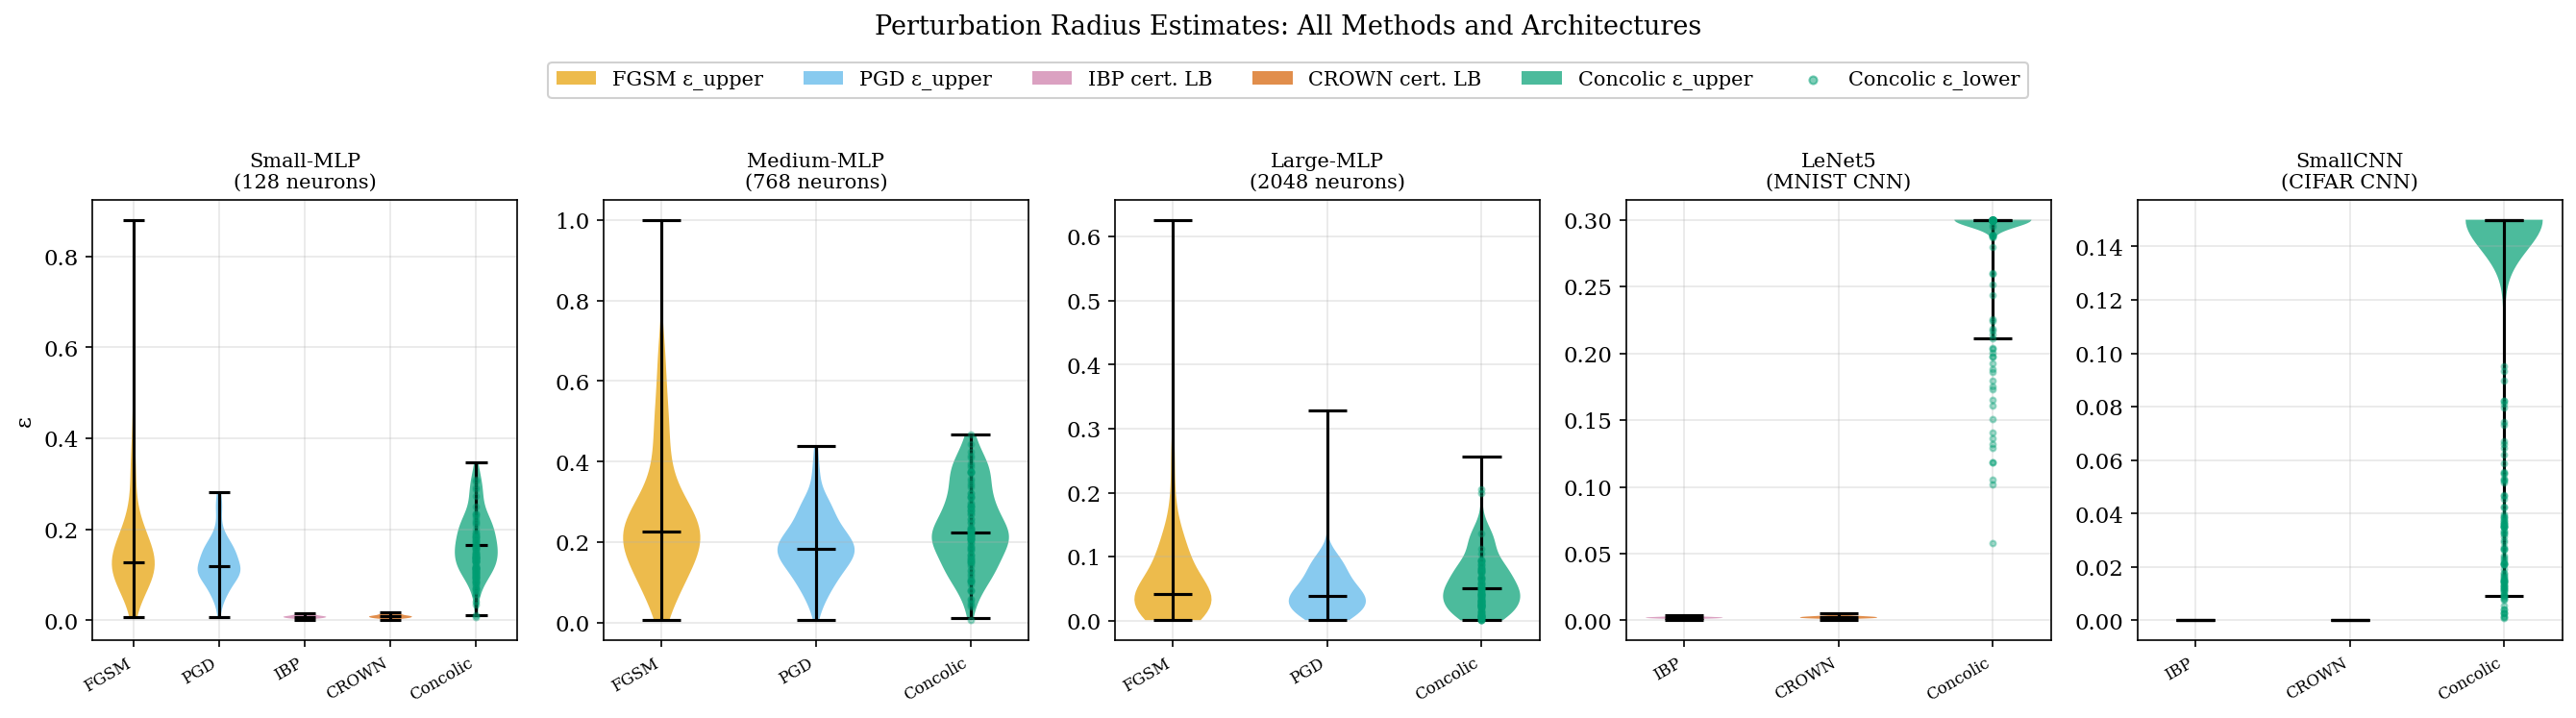

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4.5), sharey=False)

configs_fig = [
    ('Small-MLP', bl_small, co_small, cert_smlp, '128 neurons'),
    ('Medium-MLP', bl_medium, co_medium, None, '768 neurons'),
    ('Large-MLP', bl_large, co_large, None, '2048 neurons'),
    ('LeNet5', None, co_l5, cert_l5, 'MNIST CNN'),
    ('SmallCNN', None, co_cnn, cert_cnn, 'CIFAR CNN'),
]

for ax, (mname, bl_src, co_src, cert_src, subtitle) in zip(axes, configs_fig):
    sets, labels, colors = [], [], []

    if bl_src is not None:
        sets  += [get_bl(bl_src,'fgsm'), get_bl(bl_src,'pgd')]
        labels+= ['FGSM', 'PGD']
        colors+= [COLORS['fgsm'], COLORS['pgd']]

    if cert_src is not None:
        sets  += [get_cert(cert_src,'ibp'), get_cert(cert_src,'crown')]
        labels+= ['IBP', 'CROWN']
        colors+= [COLORS['ibp'], COLORS['crown']]

    co_upper = get_ps(co_src)
    sets   += [co_upper]
    labels += ['Concolic']
    colors += [COLORS['concolic']]

    positions = list(range(1, len(sets)+1))
    vp = ax.violinplot(sets, positions=positions,
                       showmedians=True, showextrema=True)
    for body, col in zip(vp['bodies'], colors):
        body.set_facecolor(col); body.set_alpha(0.7)
    for part in ['cmedians','cbars','cmins','cmaxes']:
        vp[part].set_color('black')

    # overlay concolic lower bound
    co_lower = get_ps(co_src, 'eps_lower')
    ax.scatter([len(sets)] * len(co_lower), co_lower,
               c=COLORS['concolic'], alpha=0.35, s=8, zorder=3)

    # overlay certified bounds (IBP/CROWN as horizontal lines)
    if cert_src is not None:
        ibp_idx   = labels.index('IBP') + 1
        crown_idx = labels.index('CROWN') + 1

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=8, rotation=30, ha='right')
    ax.set_title(f'{mname}\n({subtitle})', fontsize=10)
    ax.set_ylabel('ε' if mname == 'Small-MLP' else '')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['fgsm'],     alpha=0.7, label='FGSM ε_upper'),
    Patch(facecolor=COLORS['pgd'],      alpha=0.7, label='PGD ε_upper'),
    Patch(facecolor=COLORS['ibp'],      alpha=0.7, label='IBP cert. LB'),
    Patch(facecolor=COLORS['crown'],    alpha=0.7, label='CROWN cert. LB'),
    Patch(facecolor=COLORS['concolic'], alpha=0.7, label='Concolic ε_upper'),
    plt.scatter([],[],c=COLORS['concolic'], alpha=0.5, s=15, label='Concolic ε_lower'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=6,
           bbox_to_anchor=(0.5, 1.04), framealpha=0.9)
fig.suptitle('Perturbation Radius Estimates: All Methods and Architectures',
             y=1.1, fontsize=13)
plt.tight_layout()
savefig('fig_main_comparison')
plt.show()

## 6 — Figure 2: Certified vs Heuristic lower bound
Key novel contribution comparison

  Saved -> fig_certified_vs_heuristic.pdf / .png


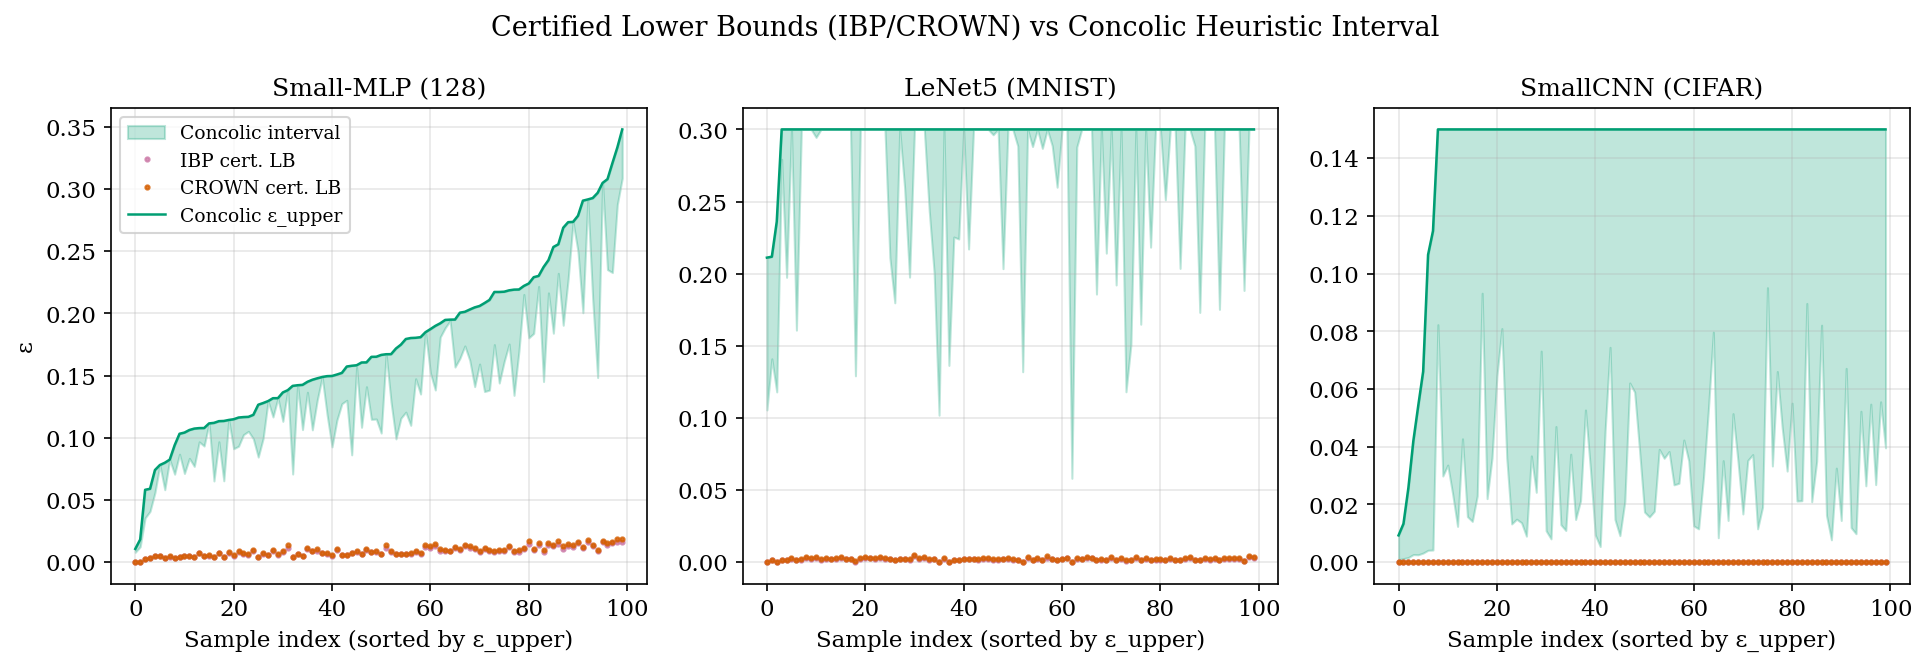

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

configs_cert = [
    ('Small-MLP (128)', cert_smlp, co_small),
    ('LeNet5 (MNIST)',  cert_l5,   co_l5),
    ('SmallCNN (CIFAR)',cert_cnn,  co_cnn),
]

for ax, (mname, cert_src, co_src) in zip(axes, configs_cert):
    n = min(len(co_src['per_sample']),
            len(cert_src['ibp']['per_sample']))

    ibp_lb    = get_cert(cert_src, 'ibp')[:n]
    crown_lb  = get_cert(cert_src, 'crown')[:n]
    heur_lb   = get_ps(co_src, 'eps_lower')[:n]
    heur_ub   = get_ps(co_src)[:n]

    x_idx = np.arange(n)

    # sort by concolic upper bound for visual clarity
    order = np.argsort(heur_ub)
    ax.fill_between(x_idx, heur_lb[order], heur_ub[order],
                    alpha=0.25, color=COLORS['concolic'],
                    label='Concolic interval')
    ax.plot(x_idx, ibp_lb[order],   '.', color=COLORS['ibp'],
            markersize=4, alpha=0.8, label='IBP cert. LB')
    ax.plot(x_idx, crown_lb[order], '.', color=COLORS['crown'],
            markersize=4, alpha=0.8, label='CROWN cert. LB')
    ax.plot(x_idx, heur_ub[order],  '-', color=COLORS['concolic'],
            linewidth=1.2, label='Concolic ε_upper')

    ax.set_title(mname)
    ax.set_xlabel('Sample index (sorted by ε_upper)')
    ax.set_ylabel('ε' if mname == 'Small-MLP (128)' else '')

axes[0].legend(fontsize=9, loc='upper left')
fig.suptitle('Certified Lower Bounds (IBP/CROWN) vs Concolic Heuristic Interval',
             fontsize=13)
plt.tight_layout()
savefig('fig_certified_vs_heuristic')
plt.show()

## 7 — Figure 3: Scalability — all methods all models

  Saved -> fig_scalability_all.pdf / .png


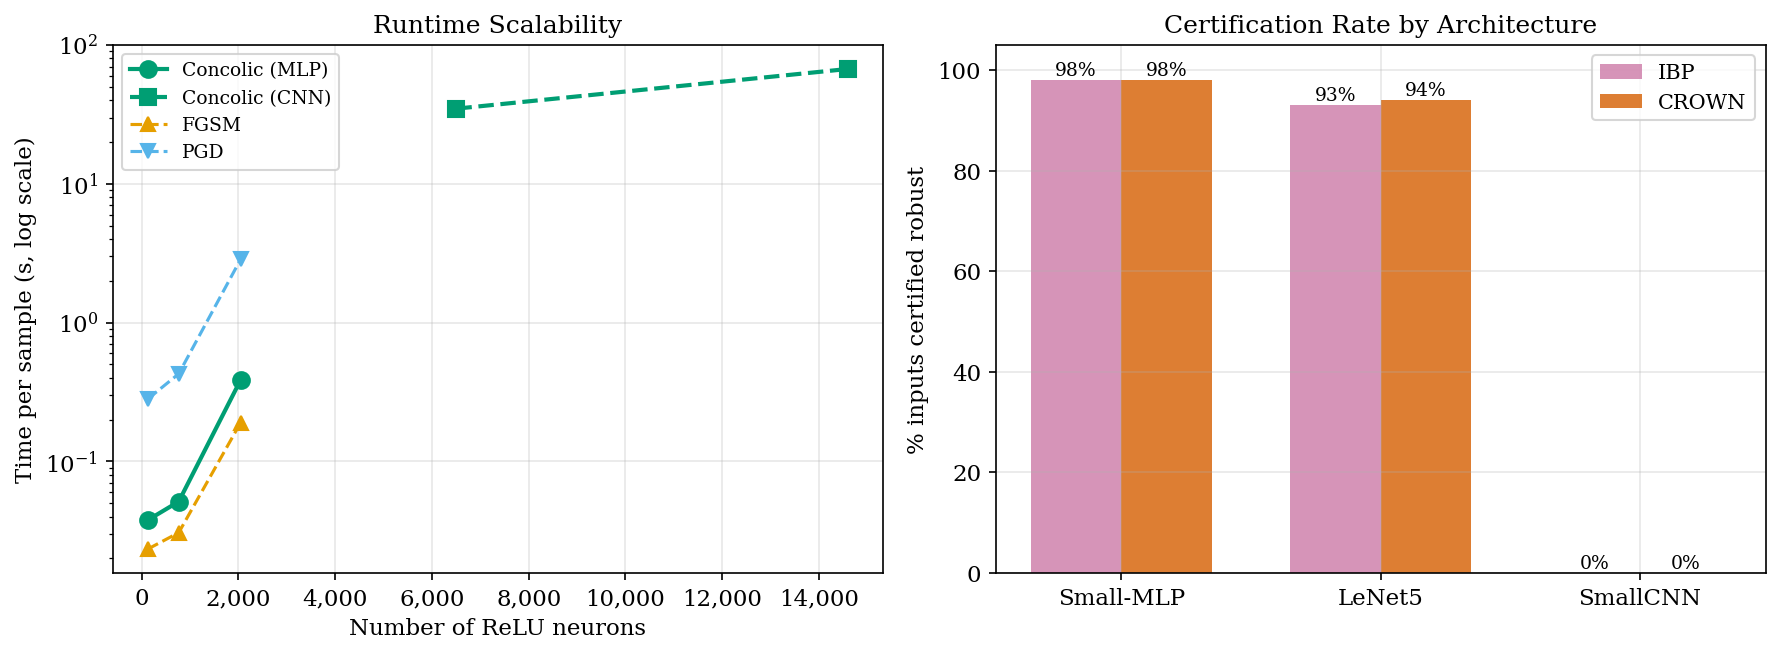

In [9]:
# Collect neuron counts — use stored value or hardcoded architecture estimate
mlp_neurons = [
    co_small["stats"].get("n_relu_neurons", 128),    # SmallMLP
    co_medium["stats"].get("n_relu_neurons", 768),   # MediumMLP
    co_large["stats"].get("n_relu_neurons", 2048),   # LargeMLP
]
cnn_neurons = [
    co_l5["stats"].get("n_relu_neurons", 6*28*28 + 16*10*10 + 120 + 84),    # LeNet5
    co_cnn["stats"].get("n_relu_neurons", 32*16*16 + 64*8*8 + 128*4*4 + 256), # SmallCNN
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Left: runtime vs neurons ──────────────────────────────────────────────────
ax1.plot(mlp_neurons,
         [co_small["stats"]["mean_runtime_sec"],
          co_medium["stats"]["mean_runtime_sec"],
          co_large["stats"]["mean_runtime_sec"]],
         "o-", color=COLORS["concolic"], linewidth=2, markersize=8, label="Concolic (MLP)")
ax1.plot(cnn_neurons,
         [co_l5["stats"]["mean_runtime_sec"],
          co_cnn["stats"]["mean_runtime_sec"]],
         "s--", color=COLORS["concolic"], linewidth=2, markersize=8, label="Concolic (CNN)")
ax1.plot(mlp_neurons,
         [bl_small["fgsm"]["stats"]["mean_runtime_sec"],
          bl_medium["fgsm"]["stats"]["mean_runtime_sec"],
          bl_large["fgsm"]["stats"]["mean_runtime_sec"]],
         "^--", color=COLORS["fgsm"], linewidth=1.5, markersize=7, label="FGSM")
ax1.plot(mlp_neurons,
         [bl_small["pgd"]["stats"]["mean_runtime_sec"],
          bl_medium["pgd"]["stats"]["mean_runtime_sec"],
          bl_large["pgd"]["stats"]["mean_runtime_sec"]],
         "v--", color=COLORS["pgd"], linewidth=1.5, markersize=7, label="PGD")

ax1.set_yscale("log")
ax1.set_xlabel("Number of ReLU neurons")
ax1.set_ylabel("Time per sample (s, log scale)")
ax1.set_title("Runtime Scalability")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

# ── Right: certified fraction vs architecture ─────────────────────────────────
models_cert = ["Small-MLP", "LeNet5", "SmallCNN"]
ibp_cert  = [
    cert_smlp["ibp"]["stats"]["fraction_certified"]*100,
    cert_l5["ibp"]["stats"]["fraction_certified"]*100,
    cert_cnn["ibp"]["stats"]["fraction_certified"]*100,
]
crown_cert = [
    cert_smlp["crown"]["stats"]["fraction_certified"]*100,
    cert_l5["crown"]["stats"]["fraction_certified"]*100,
    cert_cnn["crown"]["stats"]["fraction_certified"]*100,
]

x = np.arange(len(models_cert))
w = 0.35
ax2.bar(x - w/2, ibp_cert,   w, color=COLORS["ibp"],   alpha=0.8, label="IBP")
ax2.bar(x + w/2, crown_cert, w, color=COLORS["crown"], alpha=0.8, label="CROWN")
ax2.set_xticks(x); ax2.set_xticklabels(models_cert)
ax2.set_ylabel("% inputs certified robust")
ax2.set_title("Certification Rate by Architecture")
ax2.set_ylim(0, 105)
ax2.legend()
for i, (ib, cr) in enumerate(zip(ibp_cert, crown_cert)):
    ax2.text(i-w/2, ib+1, f"{ib:.0f}%", ha="center", fontsize=9)
    ax2.text(i+w/2, cr+1, f"{cr:.0f}%", ha="center", fontsize=9)

plt.tight_layout()
savefig("fig_scalability_all")
plt.show()


## 8 — Figure 4: Activation pattern caching analysis

  Saved -> fig_cache_analysis.pdf / .png


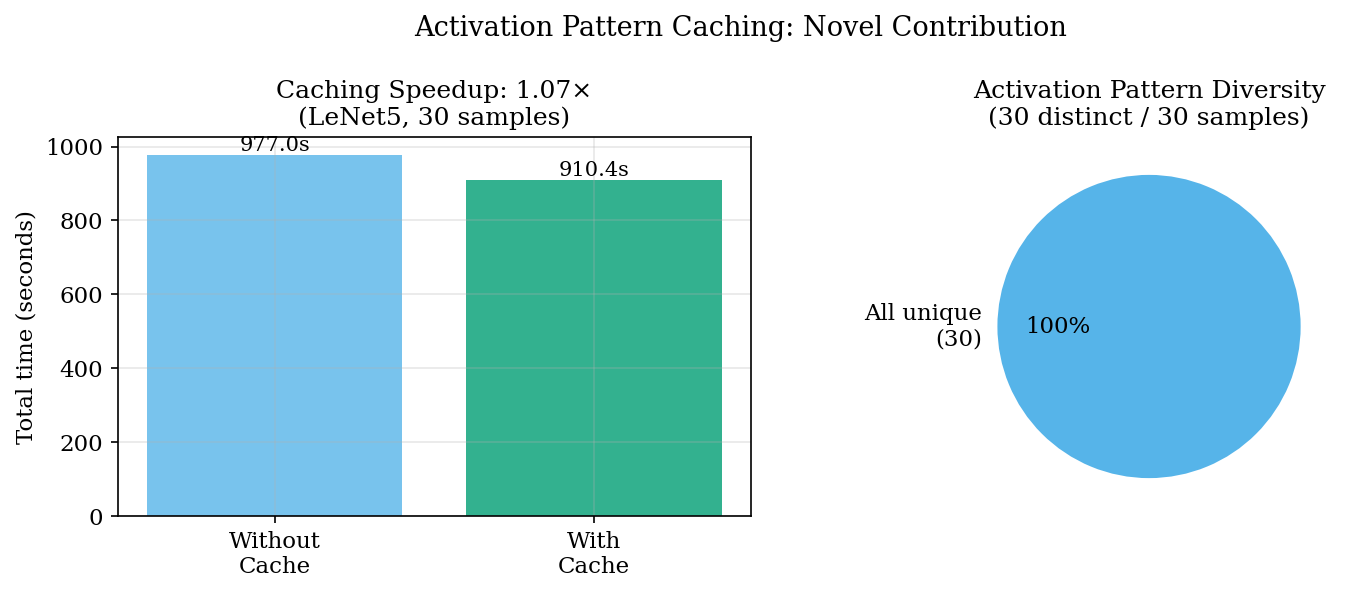

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ── Left: speedup bar ─────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(['Without\nCache', 'With\nCache'],
              [cache_a['time_without_cache_sec'],
               cache_a['time_with_cache_sec']],
              color=[COLORS['pgd'], COLORS['concolic']], alpha=0.8)
ax.set_ylabel('Total time (seconds)')
ax.set_title(f'Caching Speedup: {cache_a["speedup"]:.2f}×\n'
             f'(LeNet5, {cache_a["n_samples"]} samples)')
for bar, t in zip(bars, [cache_a['time_without_cache_sec'],
                          cache_a['time_with_cache_sec']]):
    ax.text(bar.get_x() + bar.get_width()/2, t + 0.5,
            f'{t:.1f}s', ha='center', va='bottom', fontsize=10)

# ── Right: pattern diversity pie ──────────────────────────────────────────────
ax = axes[1]
n_total    = cache_a['n_samples']
n_patterns = cache_a['n_distinct_patterns']
n_reused   = n_total - n_patterns

if n_reused > 0:
    ax.pie([n_patterns, n_reused],
           labels=[f'New patterns\n({n_patterns})',
                   f'Reused patterns\n({n_reused})'],
           colors=[COLORS['pgd'], COLORS['concolic']],
           autopct='%1.0f%%', startangle=90)
else:
    ax.pie([n_patterns],
           labels=[f'All unique\n({n_patterns})'],
           colors=[COLORS['pgd']], autopct='%1.0f%%')

ax.set_title(f'Activation Pattern Diversity\n'
             f'({n_patterns} distinct / {n_total} samples)')

fig.suptitle('Activation Pattern Caching: Novel Contribution', fontsize=13)
plt.tight_layout()
savefig('fig_cache_analysis')
plt.show()

## 9 — Figure 5: Bound gap across all models

  Saved -> fig_bound_gap_all.pdf / .png


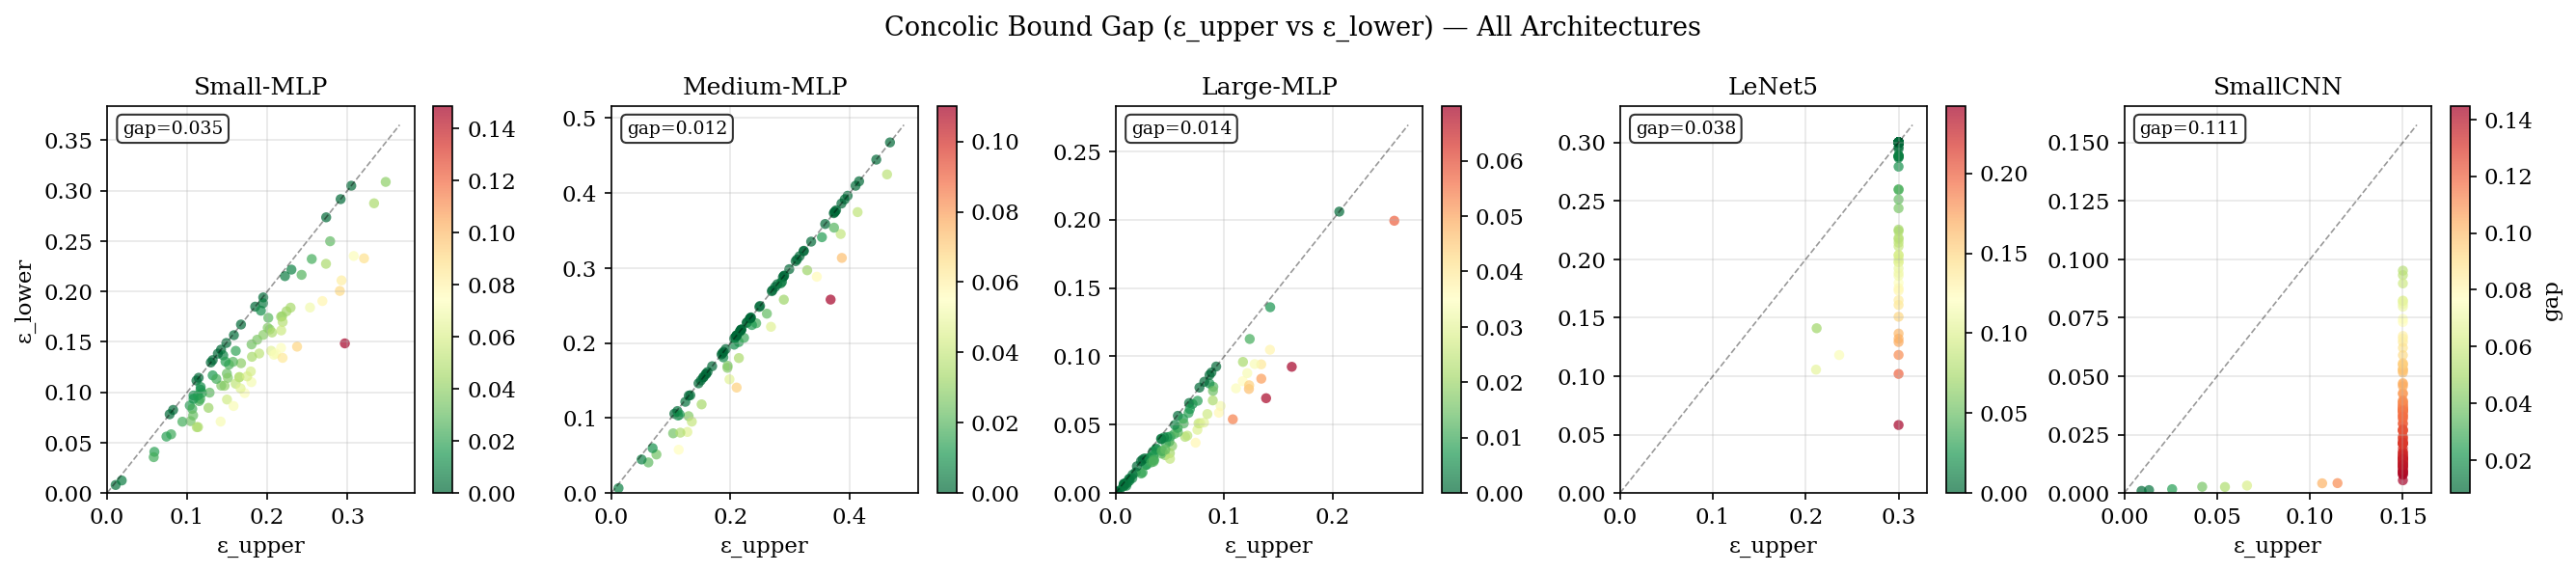

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)

all_co = [
    ('Small-MLP', co_small),
    ('Medium-MLP', co_medium),
    ('Large-MLP', co_large),
    ('LeNet5', co_l5),
    ('SmallCNN', co_cnn),
]

for ax, (mname, co_src) in zip(axes, all_co):
    uppers = get_ps(co_src)
    lowers = get_ps(co_src, 'eps_lower')
    gaps   = uppers - lowers

    sc = ax.scatter(uppers, lowers, c=gaps, cmap='RdYlGn_r',
                    alpha=0.7, s=25, edgecolors='none')
    lim = max(uppers.max(), lowers.max()) * 1.05 if len(uppers) else 1.0
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4, label='gap=0')
    ax.set_xlabel('ε_upper'); ax.set_xlim(left=0); ax.set_ylim(bottom=0)
    ax.set_ylabel('ε_lower' if mname == 'Small-MLP' else '')
    ax.set_title(mname)
    mean_gap = float(np.mean(gaps)) if len(gaps) else 0
    ax.text(0.05, 0.93, f'gap={mean_gap:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.colorbar(sc, ax=ax,
                 label='gap' if mname == 'SmallCNN' else '')

fig.suptitle('Concolic Bound Gap (ε_upper vs ε_lower) — All Architectures',
             fontsize=13)
plt.tight_layout()
savefig('fig_bound_gap_all')
plt.show()

## 10 — Final summary printout

In [12]:
print()
print('='*70)
print('  EXPERIMENT COMPLETE — TAI PAPER RESULTS')
print('='*70)

print('\n  FIGURES generated:')
for f in sorted(FIGURES_DIR.glob('*.pdf')):
    print(f'    {f.name}')

print('\n  TABLES generated:')
for f in sorted(TABLES_DIR.glob('*.json')):
    print(f'    {f.name}')

print('\n  KEY FINDINGS:')

# Finding 1: concolic uniquely provides both bounds
co_m_upper = co_medium['stats']['mean_eps_upper']
co_m_lower = co_medium['stats']['mean_eps_lower']
print(f'  1. Concolic provides BOTH bounds: ε_upper={co_m_upper:.4f}, '
      f'ε_lower={co_m_lower:.4f} (MediumMLP)')
print(f'     FGSM/PGD provide zero lower bound.')

# Finding 2: certified vs heuristic lower bound
ibp_lb  = cert_smlp['ibp']['stats']['mean_eps_certified']
heur_lb = co_small['stats']['mean_eps_lower']
print(f'  2. IBP certified LB={ibp_lb:.4f} vs Concolic heuristic LB={heur_lb:.4f} (Small-MLP)')
print(f'     Concolic LB is heuristic but covers {cert_smlp["ibp"]["stats"]["fraction_certified"]*100:.0f}% certified range.')

# Finding 3: caching
print(f'  3. Activation pattern caching: {cache_a["speedup"]:.2f}x speedup, '
      f'hit_rate={cache_a["cache_hit_rate"]:.1%}')
print(f'     {cache_a["n_distinct_patterns"]} distinct patterns / {cache_a["n_samples"]} samples')

# Finding 4: CNN extension works
print(f'  4. CNN extension: LeNet5 adv%={co_l5["stats"]["fraction_adversarial_found"]*100:.0f}%, '
      f'gap={co_l5["stats"]["mean_gap"]:.4f}')
print(f'     SmallCNN adv%={co_cnn["stats"]["fraction_adversarial_found"]*100:.0f}%, '
      f'gap={co_cnn["stats"]["mean_gap"]:.4f}')

print()
print('  All figures saved as PDF (paper-ready) and PNG (preview).')


  EXPERIMENT COMPLETE — TAI PAPER RESULTS

  FIGURES generated:
    fig1_bound_distributions.pdf
    fig2_scalability.pdf
    fig3_bound_gap_scatter.pdf
    fig4_heuristic_comparison.pdf
    fig_bound_gap_all.pdf
    fig_cache_analysis.pdf
    fig_certified_vs_heuristic.pdf
    fig_main_comparison.pdf
    fig_scalability_all.pdf

  TABLES generated:
    table1_comparison.json
    table1_main.json
    table2_tightness.json
    table3_cnn.json

  KEY FINDINGS:
  1. Concolic provides BOTH bounds: ε_upper=0.2407, ε_lower=0.2291 (MediumMLP)
     FGSM/PGD provide zero lower bound.
  2. IBP certified LB=0.0085 vs Concolic heuristic LB=0.1395 (Small-MLP)
     Concolic LB is heuristic but covers 98% certified range.
  3. Activation pattern caching: 1.07x speedup, hit_rate=0.0%
     30 distinct patterns / 30 samples
  4. CNN extension: LeNet5 adv%=3%, gap=0.0382
     SmallCNN adv%=8%, gap=0.1107

  All figures saved as PDF (paper-ready) and PNG (preview).
